# Titanic Survival Prediction

## Objective
The goal of this project is to build a machine learning model to predict whether a passenger survived the Titanic disaster based on features such as Age, Sex, Passenger Class, Fare, and engineered features like Title and FamilySize.

## 1. Data Loading

In this step, we load the Titanic dataset and inspect the initial structure.

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('titanic.csv')
df

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,"Montvila, Rev. Juozas",2,male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,"Graham, Miss. Margaret Edith",1,female,19.0,0,0,112053,30.0000,B42,S,1
888,889,"Johnston, Miss. Catherine Helen ""Carrie""",3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,"Behr, Mr. Karl Howell",1,male,26.0,0,0,111369,30.0000,C148,C,1


## 2. Data Inspection

We explore the dataset to understand its structure, data types, and missing values.

### Dataset Columns

The dataset contains passenger information from the Titanic dataset. Important columns include:

- **Survived**: Target variable indicating whether the passenger survived (1) or not (0)
- **Pclass**: Passenger class (1st, 2nd, 3rd)
- **Sex**: Gender of the passenger
- **Age**: Age of the passenger
- **SibSp**: Number of siblings/spouses aboard
- **Parch**: Number of parents/children aboard
- **Fare**: Ticket fare paid by the passenger
- **Embarked**: Port where the passenger boarded
- **Name**: Used to extract the Title feature
- **Cabin**: Dropped due to high missing values
- **Ticket**: Dropped as it was not used for prediction

In [40]:
df['Cabin'].nunique()

147

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    object 
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [43]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208,0.383838
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429,0.486592
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [44]:
df.isna().sum()

PassengerId      0
Name             0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Survived         0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

## Data Preprocessing & Feature Engineering

## 3. Data Preprocessing

The dataset was cleaned by removing unnecessary columns and handling missing values.

- Columns such as PassengerId, Name, Ticket, and Cabin were dropped as they do not contribute directly to prediction or contain excessive missing values.
- SibSp and Parch were removed after creating the FamilySize feature to avoid redundancy.

## 4. Feature Engineering

The following new features were created to improve model performance:

- **Title**: Extracted from the Name column to capture social status and gender-related information (e.g., Mr, Mrs, Miss, Master). This helped in better understanding survival patterns.

- **FamilySize**: Created by combining SibSp (siblings/spouses) and Parch (parents/children), along with the passenger themselves:
  FamilySize = SibSp + Parch + 1  
  This represents the total number of family members traveling together.

- **IsAlone**: A binary feature derived from FamilySize:
  - 1 → Passenger is traveling alone  
  - 0 → Passenger is traveling with family  
  This helps identify whether traveling alone impacted survival.

- **Fare_log**: Applied log transformation to the Fare column to reduce skewness and improve model performance.

In [46]:
# #feature engineering
# df['Deck'] = df['Cabin'].str[0]
# df['Deck'] = df['Deck'].fillna("Unknown")

The Deck feature was excluded due to a high number of missing values and its negative impact on model performance.

In [47]:
df['Title']= df['Name'].str.extract(' ([A-Za-z]+)\.', expand= False)
df['Title']

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

In [48]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [49]:
#normalize meaningful titles
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

#group truly rare ones
df['Title'] = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)

In [50]:
#missing value imputation of age 
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [51]:
df=df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,Title
0,3,male,22.0,1,0,7.2500,S,0,Mr
1,1,female,38.0,1,0,71.2833,C,1,Mrs
2,3,female,26.0,0,0,7.9250,S,1,Miss
3,1,female,35.0,1,0,53.1000,S,1,Mrs
4,3,male,35.0,0,0,8.0500,S,0,Mr
...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,0,Rare
887,1,female,19.0,0,0,30.0000,S,1,Miss
888,3,female,21.0,1,2,23.4500,S,0,Miss
889,1,male,26.0,0,0,30.0000,C,1,Mr


- **PassengerId** is just an identifier and does not carry predictive information.
- **Name** and **Ticket** are high-cardinality text features and are not directly useful after extracting relevant information (such as Title).
- **Cabin** contains a large number of missing values, which introduces noise into the model.

In [52]:
df.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
Title       0
dtype: int64

In [53]:
#combine SibSp and Parch column
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1                       
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df     


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived,Title,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,0,Mr,2,0
1,1,female,38.0,1,0,71.2833,C,1,Mrs,2,0
2,3,female,26.0,0,0,7.9250,S,1,Miss,1,1
3,1,female,35.0,1,0,53.1000,S,1,Mrs,2,0
4,3,male,35.0,0,0,8.0500,S,0,Mr,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,0,Rare,1,1
887,1,female,19.0,0,0,30.0000,S,1,Miss,1,1
888,3,female,21.0,1,2,23.4500,S,0,Miss,4,0
889,1,male,26.0,0,0,30.0000,C,1,Mr,1,1


### Family Features

- `FamilySize` represents the total number of family members traveling together, including the passenger.
- It is calculated using: SibSp + Parch + 1.
- `IsAlone` is a binary feature indicating whether the passenger was traveling alone (1) or with family (0).

In [54]:
df.drop(columns=["SibSp", "Parch"],axis=1, inplace=True)

- **SibSp** and **Parch** were combined into a more meaningful feature (FamilySize), so keeping them would create redundancy.

In [55]:
df['Age'].skew()

np.float64(0.4366721111514754)

In [56]:
df['Fare'].skew()

np.float64(4.787316519674893)

In [57]:
df['Fare_log'] = np.log1p(df['Fare'])

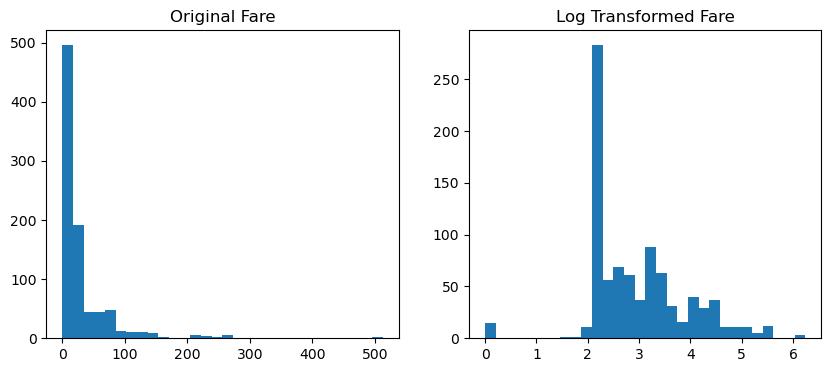

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df['Fare'], bins=30)
plt.title("Original Fare")

plt.subplot(1,2,2)
plt.hist(df['Fare_log'], bins=30)
plt.title("Log Transformed Fare")

plt.show()

### Insight: Log Transformation of Fare
The **Fare** column was transformed using **np.log1p** to improve data quality for modeling:
- **Reducing Skewness:** The original fare distribution was highly right-skewed. Applying a log transformation helps normalize the distribution, which is especially beneficial for models like Logistic Regression and SVM.
- **Handling Zero Fares:** We used `log1p` ($log(1+x)$) instead of a standard $log(x)$ to ensure the calculation is valid for passengers who had a fare of 0.
- **Improved Scaling:** This transformation helps the model better interpret the price differences by reducing the impact of extreme outliers (high-end ticket prices).

In [59]:
# Dropping original 'Fare' as 'Fare_log' has been created to handle skewness and avoid redundancy.
df.drop('Fare', axis=1, inplace=True)

In [60]:
print(df.columns)

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'Survived', 'Title', 'FamilySize',
       'IsAlone', 'Fare_log'],
      dtype='object')


## 5. Exploratory Data Analysis (EDA)

In this section, the dataset is explored to understand the key factors affecting passenger survival on the Titanic. The analysis focuses on important variables such as gender, passenger class, age, fare, family structure, embarkation port, and title.

### Key Questions
- What is the overall survival distribution in the dataset?
- Did female passengers survive more often than male passengers?
- How did passenger class affect survival?
- Did passengers traveling alone survive less than those traveling with family?
- Was family size related to survival chances?
- Which age group showed the highest survival tendency?
- Did age alone clearly distinguish survivors from non-survivors?
- Did passengers who paid higher fares survive more often?
- Did the embarkation port affect survival?
- How did survival rates vary across title groups such as Mr, Mrs, Miss, and Master?
- Which title group had the highest and lowest survival rates?
- How did survival change when Title and Pclass were considered together?

In [61]:
#Age distribution by title
df.groupby('Title')['Age'].median()

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

### Insight
The median age varies significantly across title groups.

'Master' represents young children, while 'Mr' and 'Mrs' represent adults, and 'Rare' titles correspond to older individuals.

This shows that the Title feature indirectly captures age groups, making it a meaningful feature for prediction.

In [62]:
df.groupby('Title')['Survived'].mean()

Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64

### Insight
Survival rates differ significantly across title groups.

Passengers with titles 'Mrs' and 'Miss' had the highest survival rates, while 'Mr' had the lowest. 'Master' (children) also had relatively higher survival.

This pattern reflects the "women and children first" evacuation priority.

In [63]:
df[df['Title'] == 'Rare']['Survived'].mean()

np.float64(0.34782608695652173)

Some rare titles may indicate higher social status, but the data does not show a consistently higher survival rate for this group.

### Question: What is the survival distribution in the dataset?

In [64]:
#survival distribution
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

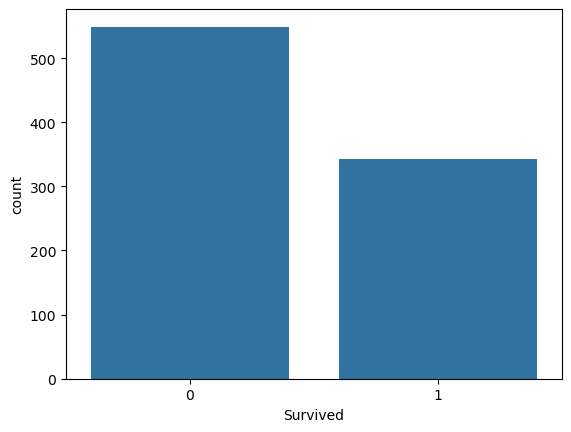

In [65]:
sns.countplot(x='Survived', data=df)

### Insight
The number of non-survivors is higher than survivors, indicating a class imbalance in the dataset.

### Question: Did females survive more than males?

<Axes: xlabel='Sex', ylabel='count'>

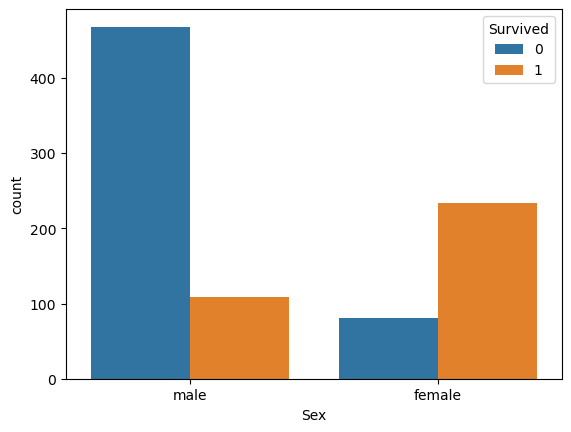

In [66]:
#Surviva by Sex
sns.countplot(x="Sex", hue="Survived", data=df)

### Insight
Female passengers had significantly higher survival rates, likely due to evacuation priority given to women and children.

### Question: Did passengers traveling alone survive less than passengers traveling with family?

<Axes: xlabel='IsAlone', ylabel='count'>

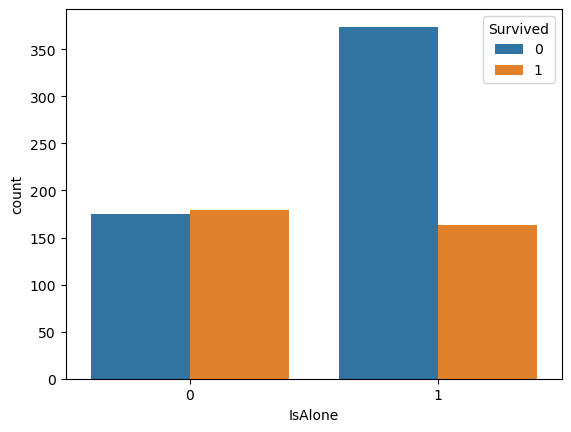

In [67]:
# not alone(0) and alone(1)
sns.countplot(x="IsAlone", hue="Survived", data=df)

### Insight
Passengers traveling alone had significantly lower survival rates compared to those traveling with family.

### Question: Does family size have any relation to survival?

<Axes: xlabel='FamilySize', ylabel='count'>

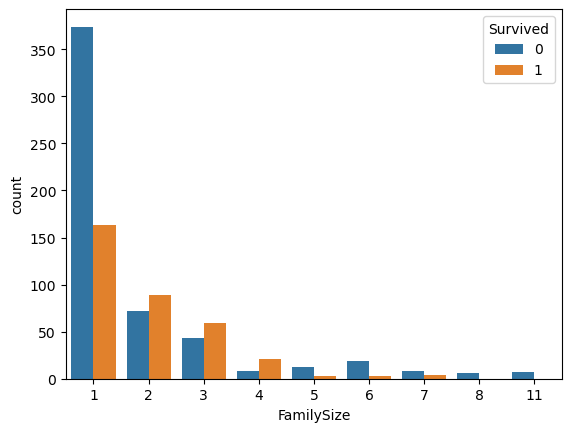

In [68]:
#FamilySize vs Survived
sns.countplot(x="FamilySize", hue="Survived", data=df)

### Insight
Passengers traveling alone had lower survival rates, while those with small families (2–4 members) had higher chances of survival.
Larger families showed significantly lower survival rates

### Question: How does passenger class affect survival?

<Axes: xlabel='Pclass', ylabel='count'>

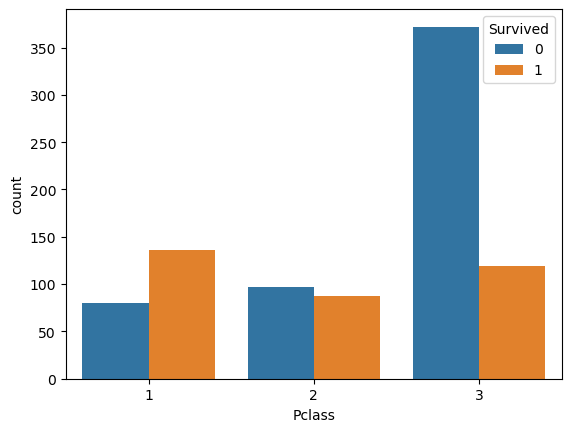

In [69]:
#Survival by passengers class
sns.countplot(x='Pclass',hue='Survived',data=df)

### Insight

Passengers in first class had a higher survival rate compared to second and third class, showing the importance of socio-economic status.


### Question: Does survival change when Title and Pclass are considered together?

In [70]:
df.groupby(['Title','Pclass'])['Survived'].mean() 

Title   Pclass
Master  1         1.000000
        2         1.000000
        3         0.392857
Miss    1         0.958333
        2         0.942857
        3         0.500000
Mr      1         0.345794
        2         0.087912
        3         0.112853
Mrs     1         0.976744
        2         0.902439
        3         0.500000
Rare    1         0.533333
        2         0.000000
Name: Survived, dtype: float64

### Insight
- Survival rates are strongly influenced by both passenger class and social group (Title). 

- Passengers in first class, especially women (Mrs, Miss) and children (Master), had the highest survival rates, often close to 100%. In contrast, men (Mr), particularly in second and third class, had the lowest survival rates.

- This indicates that both socio-economic status (Pclass) and demographic factors (Title) played a critical role in survival, with clear evidence of priority given to women and children in higher classes.

### Question: Does age alone clearly separate survivors from non-survivors?

<Axes: xlabel='Age', ylabel='Count'>

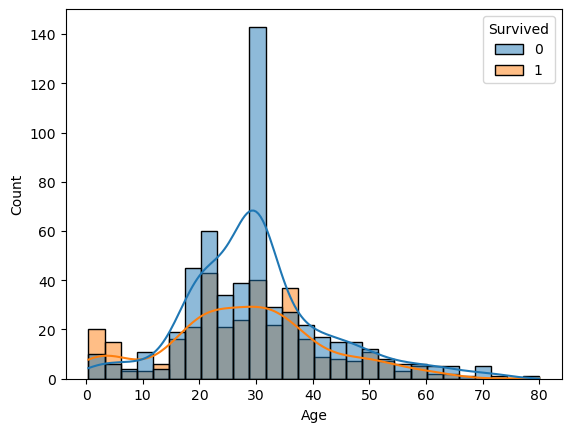

In [71]:
# Age vs Survival
sns.histplot(data=df, x="Age", hue="Survived", kde=True)

### Insight
Most passengers were between 20 and 40 years old. While younger passengers show slightly higher survival rates, there is significant overlap between survivors and non-survivors across all age groups. This indicates that age alone is not a strong predictor of survival.

### Question: Did passengers who paid higher fare survive more often?

<Axes: xlabel='Survived', ylabel='Fare_log'>

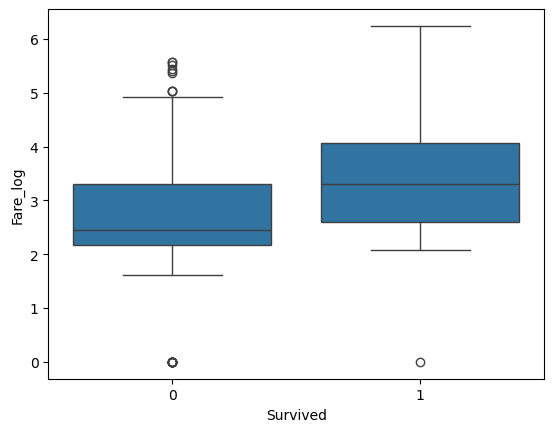

In [72]:
# Fare vs Survival
sns.boxplot(x="Survived", y="Fare_log", data=df)

### Insight
Passengers with higher fares had better survival rates, indicating the influence of passenger class on survival.

### Question: Does the embarkation port affect survival?

<Axes: xlabel='Embarked', ylabel='count'>

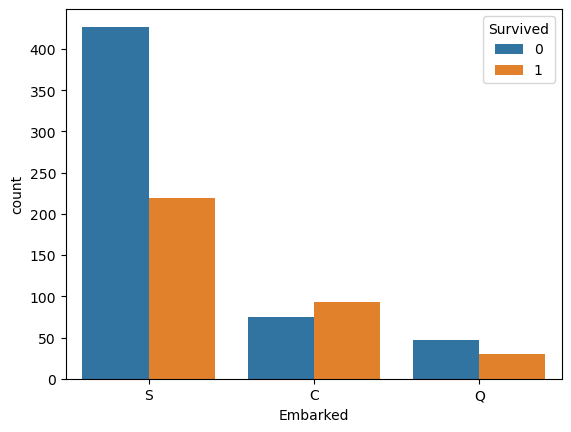

In [73]:
sns.countplot(x="Embarked", hue="Survived", data=df)

### Insight
Passengers who boarded at Cherbourg had a higher survival rate compared to other embarkation points.

In [74]:
#Encode
df=pd.get_dummies(df, columns=["Sex","Title", "Embarked"], drop_first=True)

### Outlier Detection

Boxplots were used to check for possible outliers in numerical features after preprocessing and feature engineering.

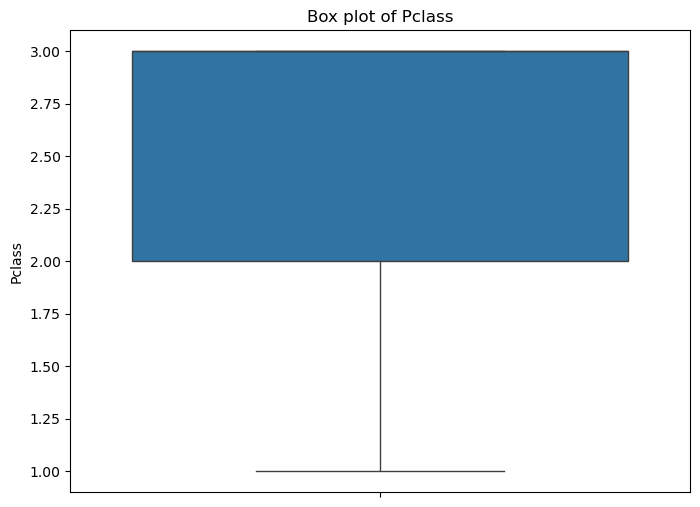

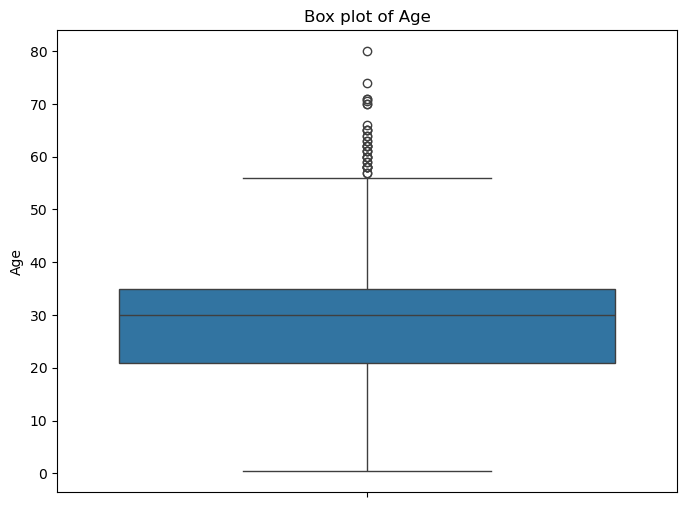

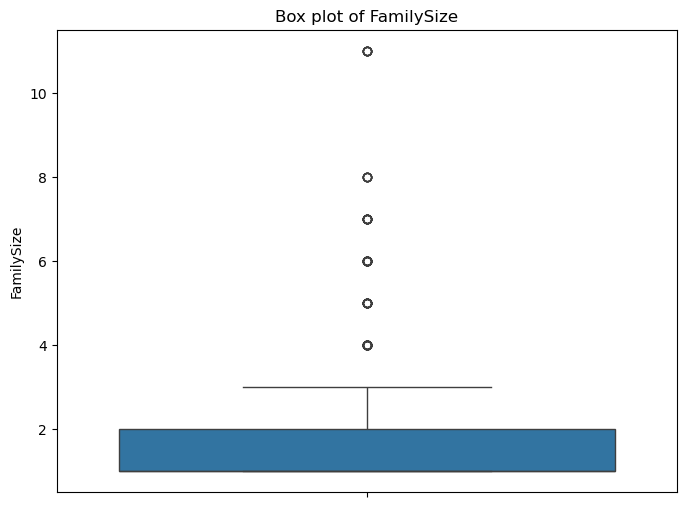

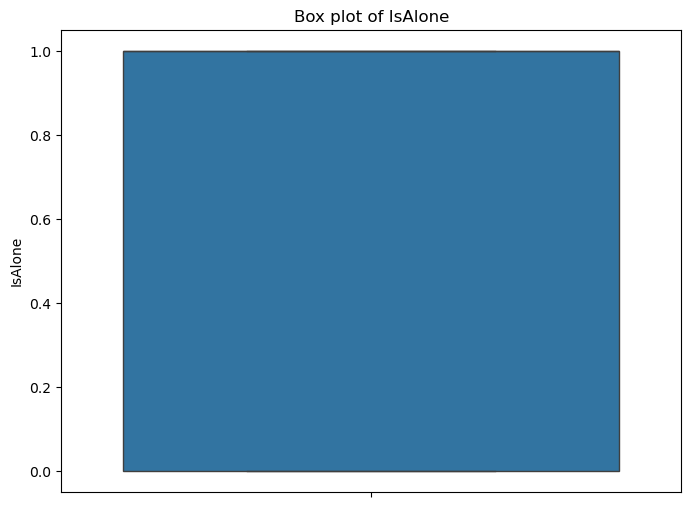

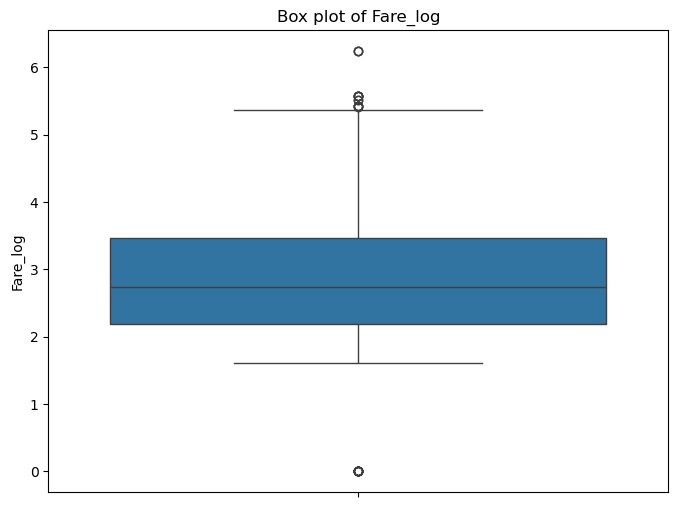

In [75]:
import seaborn as sns
for col in df.select_dtypes(include= ["number"]).drop('Survived' , axis =1).columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(df[col])
    plt.title(f"Box plot of {col}");
    
    

### Insight

Some numerical features show outliers, especially fare-related and family-size features. However, these values represent real passenger information rather than clear data errors, so they were not removed. The Fare feature was handled using log transformation to reduce skewness.

## 6. Train-Test Split and Scaling

In [77]:
# Define features and target
from sklearn.naive_bayes import  GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 12), (179, 12), (712,), (179,))

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  

## 7. Model Training & Evaluation

In this section, multiple machine learning models are trained and evaluated using accuracy, precision, recall, and F1-score.

### Logistic Regression

In [79]:
from sklearn.linear_model import LogisticRegression
logi = LogisticRegression()
logi.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [80]:
train_pred=logi.predict(X_train)
test_pred=logi.predict(X_test)

In [81]:
print("train_accuracy:",accuracy_score(y_train,train_pred))
print("test_accuracy:", accuracy_score(y_test, test_pred))
print("\n confusion Matrix: \n", confusion_matrix(y_test,test_pred))
print("\n classification Report: \n", classification_report(y_test,test_pred))

train_accuracy: 0.8370786516853933
test_accuracy: 0.8156424581005587

 confusion Matrix: 
 [[88 17]
 [16 58]]

 classification Report: 
               precision    recall  f1-score   support

           0       0.85      0.84      0.84       105
           1       0.77      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### Random Forest Classifier

In [82]:
from sklearn.ensemble import RandomForestClassifier

random = RandomForestClassifier(n_estimators=500,n_jobs=1,random_state=42)
random.fit(X_train,y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
train_ypred=random.predict(X_train)
test_ypred=random.predict(X_test)

In [84]:
print("train_accuracy:",accuracy_score(y_train,train_ypred))
print("test_accuracy:", accuracy_score(y_test, test_ypred))
print("\n confusion Matrix: \n", confusion_matrix(y_test,test_ypred))
print("\n classification Report: \n", classification_report(y_test,test_ypred))

train_accuracy: 0.9803370786516854
test_accuracy: 0.8435754189944135

 confusion Matrix: 
 [[92 13]
 [15 59]]

 classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       105
           1       0.82      0.80      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.84      0.84      0.84       179



In [85]:
from sklearn.model_selection import GridSearchCV

Random_grid=RandomForestClassifier(random_state=42)

param_grid={
    'max_depth':[5,10,15],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,5],
    'max_features':['sqrt','log2']
}

grid_search = GridSearchCV(
    estimator=Random_grid,
    param_grid=param_grid,
    n_jobs=-1,
    cv=5,
    scoring ='accuracy'  
)
grid_search.fit(X_train,y_train)

grid_search.best_params_

{'max_depth': 5,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10}

In [86]:
final_grid=grid_search.best_estimator_

print("Best CV Score:", grid_search.best_score_)
print("train_accuracy:",accuracy_score(y_train,final_grid.predict(X_train)))
print("test_accuracy:", accuracy_score(y_test, final_grid.predict(X_test)))
print("\n confusion Matrix: \n", confusion_matrix(y_test,final_grid.predict(X_test)))
print("\n classification Report: \n", classification_report(y_test,final_grid.predict(X_test)))

Best CV Score: 0.8314094356347876
train_accuracy: 0.8539325842696629
test_accuracy: 0.8212290502793296

 confusion Matrix: 
 [[92 13]
 [19 55]]

 classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



### SVM

In [87]:
from sklearn.svm import SVC

#Linear
svm=SVC(kernel='linear')
svm.fit(X_train,y_train)

trainy = svm.predict(X_train)
testy = svm.predict(X_test)

print("Train accuracy:", accuracy_score(y_train,trainy))
print("Test accuracy:", accuracy_score(y_test,testy))
print("\n confusion matrix: \n", confusion_matrix(y_test,testy))
print("\n classification report: \n", classification_report(y_test,testy))

Train accuracy: 0.827247191011236
Test accuracy: 0.8156424581005587

 confusion matrix: 
 [[91 14]
 [19 55]]

 classification report: 
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [88]:
#Non-linear
svm_=SVC(kernel='rbf')
svm_.fit(X_train,y_train)

train_y = svm_.predict(X_train)
test_y = svm_.predict(X_test)

print("Train accuracy:", accuracy_score(y_train,train_y))
print("Test accuracy:", accuracy_score(y_test,test_y ))
print("\n confusion matrix: \n", confusion_matrix(y_test,test_y ))
print("\n classification report: \n", classification_report(y_test,test_y ))

Train accuracy: 0.8455056179775281
Test accuracy: 0.8156424581005587

 confusion matrix: 
 [[92 13]
 [20 54]]

 classification report: 
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



#### XGBoost

In [89]:
import xgboost as xgb

xgb_cls = xgb.XGBClassifier(
    max_depth=3,
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    n_jobs=-1,
    random_state=42
) 

xgb_cls.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [90]:
ypred_train = xgb_cls.predict(X_train)
ypred_test = xgb_cls.predict(X_test)

print("Train accuracy:", accuracy_score(y_train,ypred_train))
print("Test accuracy:", accuracy_score(y_test,ypred_test ))
print("\n confusion matrix: \n", confusion_matrix(y_test,ypred_test ))
print("\n classification report: \n", classification_report(y_test,ypred_test))

Train accuracy: 0.9044943820224719
Test accuracy: 0.8547486033519553

 confusion matrix: 
 [[92 13]
 [13 61]]

 classification report: 
               precision    recall  f1-score   support

           0       0.88      0.88      0.88       105
           1       0.82      0.82      0.82        74

    accuracy                           0.85       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.85      0.85      0.85       179



## 8. Model Comparison

### Model Performance Comparison

| Model                | Train Accuracy | Test Accuracy | Precision (Class 1) | Recall (Class 1) | F1-score (Class 1) |
|---------------------|---------------|--------------|---------------------|------------------|--------------------|
| Logistic Regression | 0.84          | 0.82         | 0.77                | 0.78             | 0.78               |
| Random Forest       | 0.98          | 0.84         | 0.82                | 0.78             | 0.80               |
| Tuned Random Forest | 0.85          | 0.82         | 0.81                | 0.74             | 0.77               |
| SVM (Linear)        | 0.83          | 0.82         | 0.80                | 0.74             | 0.77               |
| SVM (Non-linear)    | 0.85          | 0.82         | 0.81                | 0.73             | 0.77               |
| XGBoost             | 0.91          | 0.86         | 0.83                | 0.84             | 0.83               |

### Insight

XGBoost achieved the best overall performance with the highest test accuracy (~86%) and balanced precision, recall, and F1-score.

Random Forest showed signs of overfitting due to very high training accuracy compared to test accuracy. After tuning, overfitting was reduced, but overall performance slightly decreased.

Logistic Regression and SVM provided stable and consistent results, but did not outperform ensemble models.

Overall, XGBoost was selected as the final model due to its strong generalization and balanced performance.

## 9. Conclusion

In this project, an end-to-end machine learning workflow was developed to predict Titanic passenger survival.

The data was cleaned, important patterns were explored through EDA, and new features such as `Title`, `FamilySize`, `IsAlone`, and `Fare_log` were created to improve model performance.

Several classification models were trained and compared, including Logistic Regression, Random Forest, SVM, and XGBoost. Among them, XGBoost achieved the best overall performance with approximately 86% test accuracy and balanced precision, recall, and F1-score.

The analysis showed that survival was strongly influenced by factors such as Sex, Passenger Class, Title, and the log-transformed Fare feature. Age alone was not a strong predictor because survivors and non-survivors overlapped across age groups.

Overall, this project demonstrates the importance of data preprocessing, feature engineering, EDA, and model comparison in building a reliable machine learning classification model.